# Explainable Machine Learning Prediction of Cesarean Section Delivery in India

## Exploratory Data Analysis

This notebook performs exploratory data analysis on the cleaned NFHS-5 modeling dataset.

The analysis includes:

- Target-variable distribution
- Maternal characteristics
- Socioeconomic characteristics
- Obstetric history
- Antenatal-care utilization
- ANC providers
- ANC quality and counselling
- Pregnancy complications
- Facility characteristics
- Statistical comparisons
- Correlation and redundancy analysis
- Missing-value analysis

The findings describe associations only and do not establish causation.

## 1. Load Libraries and Data

The cleaned modeling dataset created in the data-preparation notebook is loaded from the saved Parquet file.

In [1]:
# Import the libraries used in the EDA
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, mannwhitneyu

In [2]:
# Check the likely locations of the processed dataset
possible_paths = [
    Path("../data/processed/df_model_v1.parquet"),
    Path("data/processed/df_model_v1.parquet")
]

# Select the first path that exists
data_path = next(
    (path for path in possible_paths if path.exists()),
    None
)

# Stop with a clear error if the file is not found
if data_path is None:
    raise FileNotFoundError(
        "df_model_v1.parquet was not found. Run this notebook from the "
        "project root or the notebooks folder."
    )

# Load the cleaned modeling dataset
df_model = pd.read_parquet(data_path)

# Verify that the dataset loaded correctly
print("Dataset shape:", df_model.shape)
display(df_model.head())

Dataset shape: (201311, 49)


,respondent_id,birth_index,cluster_number,household_number,respondent_line_number,sample_weight,primary_sampling_unit,sample_stratum_v022,sample_stratum_v023,state,...,urine_sample_during_pregnancy,blood_sample_during_pregnancy,told_about_pregnancy_complications,counselled_vaginal_bleeding,counselled_convulsions,counselled_prolonged_labour,counselled_severe_abdominal_pain,counselled_high_blood_pressure,convulsions_during_pregnancy,swelling_during_pregnancy
0,0100101399 02,1,113,99,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,1
1,0100101357 02,1,113,57,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,1
2,0100101358 04,1,113,58,4,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,0
3,0100101380 02,1,113,80,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,0
4,0100103022 04,1,130,22,4,201224,130,121,121,1,...,1,1,1,1,1,1,1,1,0,0


In [3]:
# Display the data types
display(df_model.dtypes.to_frame("dtype"))

# Check for duplicate rows
print("Duplicate rows:", df_model.duplicated().sum())

# Confirm the target distribution
display(df_model["csection"].value_counts().sort_index())

,dtype
respondent_id,str
birth_index,int64
cluster_number,int64
household_number,int64
respondent_line_number,int64
sample_weight,int64
primary_sampling_unit,int64
sample_stratum_v022,int64
sample_stratum_v023,int64
state,int64


Duplicate rows: 0


csection
0    156569
1     44742
Name: count, dtype: Int64

## 2. Reusable EDA Functions

These functions keep the analysis consistent and reduce repeated code.

### Reusable Function: Numeric Variable Analysis

This function performs exploratory data analysis for a numeric variable by generating summary statistics, visualizations, and comparisons between vaginal and Cesarean deliveries.

In [4]:
# Analyze a numeric variable and compare it across delivery types
def analyze_numeric_feature(
    data,
    feature,
    feature_label,
    x_label,
    variable_type="continuous",
    structural_missing_note=None
):
    # Select the feature and target columns
    analysis_data = data[[feature, "csection"]].copy()

    # Convert the feature to numeric values
    analysis_data[feature] = pd.to_numeric(
        analysis_data[feature],
        errors="coerce"
    )

    # Count the missing values
    missing_count = analysis_data[feature].isna().sum()

    # Calculate the missing-value percentage
    missing_percent = analysis_data[feature].isna().mean() * 100

    # Display the overall summary
    print(f"{feature_label} summary:")
    display(analysis_data[feature].describe())

    # Display the missing-value information
    print(f"Missing values: {missing_count} ({missing_percent:.2f}%)")

    # Explain structural missingness when needed
    if structural_missing_note is not None:
        print(f"Note: {structural_missing_note}")

    # Calculate statistics for each delivery type
    group_summary = (
        analysis_data
        .groupby("csection")[feature]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )

    # Rename the delivery groups
    group_summary.index = [
        "Vaginal delivery",
        "Cesarean section"
    ]

    # Display the comparison table
    print(f"{feature_label} by delivery type:")
    display(group_summary)

    # Plot the overall distribution
    plt.figure(figsize=(8, 5))
    plt.hist(
        analysis_data[feature].dropna(),
        bins=30
    )
    plt.title(f"Distribution of {feature_label}")
    plt.xlabel(x_label)
    plt.ylabel("Number of Mothers")
    plt.tight_layout()
    plt.show()

    # Use a boxplot for continuous variables
    if variable_type == "continuous":
        vaginal_values = analysis_data.loc[
            analysis_data["csection"] == 0,
            feature
        ].dropna()

        csection_values = analysis_data.loc[
            analysis_data["csection"] == 1,
            feature
        ].dropna()

        plt.figure(figsize=(6, 5))
        plt.boxplot(
            [vaginal_values, csection_values],
            tick_labels=["Vaginal", "Cesarean"]
        )
        plt.title(f"{feature_label} by Delivery Type")
        plt.ylabel(x_label)
        plt.tight_layout()
        plt.show()

    # Use a rate plot for ordered variables
    elif variable_type == "ordered":
        feature_rate = (
            analysis_data
            .groupby(feature)["csection"]
            .mean()
            .mul(100)
        )

        plt.figure(figsize=(8, 5))
        plt.plot(
            feature_rate.index,
            feature_rate.values,
            marker="o",
            linewidth=2
        )
        plt.title(f"C-section Rate by {feature_label}")
        plt.xlabel(x_label)
        plt.ylabel("C-section Rate (%)")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError(
            "variable_type must be either 'continuous' or 'ordered'."
        )

    # Return the summary table for later use
    return group_summary

### Reusable Function: Categorical Variable Analysis

This function performs exploratory data analysis for a categorical variable by summarizing category frequencies, calculating C-section rates, and generating comparison visualizations.

In [5]:
# Analyze a categorical variable and compare C-section rates
def analyze_categorical_feature(
    data,
    feature,
    feature_label,
    category_labels=None,
    category_order=None,
    small_group_threshold=100,
    structural_missing_note=None
):
    # Select the feature and target columns
    analysis_data = data[[feature, "csection"]].copy()

    # Count the original missing values
    missing_count = analysis_data[feature].isna().sum()

    # Calculate the missing-value percentage
    missing_percent = analysis_data[feature].isna().mean() * 100

    # Replace codes with readable labels when provided
    if category_labels is not None:
        analysis_data[feature] = analysis_data[feature].map(category_labels)

    # Keep missing values as a visible category
    analysis_data[feature] = (
        analysis_data[feature]
        .astype("string")
        .fillna("Missing")
    )

    # Display the missing-value information
    print(f"Missing values: {missing_count} ({missing_percent:.2f}%)")

    # Explain structural missingness when needed
    if structural_missing_note is not None:
        print(f"Note: {structural_missing_note}")

    # Count observations in each category
    category_counts = analysis_data[feature].value_counts(dropna=False)

    # Calculate the percentage in each category
    category_percent = category_counts / len(analysis_data) * 100

    # Calculate the C-section rate for each category
    category_rate = (
        analysis_data
        .groupby(feature)["csection"]
        .mean()
        .mul(100)
    )

    # Combine all results into one table
    category_summary = pd.DataFrame({
        "count": category_counts,
        "percent": category_percent,
        "csection_rate": category_rate
    })

    # Apply a logical order when provided
    if category_order is not None:
        available_order = [
            category
            for category in category_order
            if category in category_summary.index
        ]

        remaining_categories = [
            category
            for category in category_summary.index
            if category not in available_order
        ]

        category_summary = category_summary.reindex(
            available_order + remaining_categories
        )

    # Round the percentages
    category_summary[
        ["percent", "csection_rate"]
    ] = category_summary[
        ["percent", "csection_rate"]
    ].round(2)

    # Name and display the summary table
    category_summary.index.name = feature_label
    print(f"{feature_label} summary:")
    display(category_summary)

    # Find categories with very small sample sizes
    small_categories = category_summary.loc[
        category_summary["count"] < small_group_threshold
    ].index.tolist()

    # Display a warning for small categories
    if small_categories:
        print(
            f"Caution: categories with fewer than {small_group_threshold} "
            f"observations should be interpreted carefully: {small_categories}"
        )

    # Plot the C-section rate for each category
    plt.figure(figsize=(8, 5))
    plt.bar(
        category_summary.index.astype(str),
        category_summary["csection_rate"]
    )
    plt.title(f"C-section Rate by {feature_label}")
    plt.xlabel(feature_label)
    plt.ylabel("C-section Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Return the summary table for later use
    return category_summary

### Reusable Function: Binary Variable Group Analysis

This function analyzes a group of related binary variables by summarizing their frequencies, comparing C-section rates between women with and without each characteristic, and visualizing the results in a grouped bar chart.

In [6]:
# Analyze a group of related binary variables
def analyze_binary_group(
    data,
    features,
    feature_labels,
    group_label
):
    # Store one summary row for each binary feature
    rows = []

    # Process every binary feature in the group
    for feature in features:
        # Keep non-missing values for the current feature
        feature_data = data[[feature, "csection"]].dropna().copy()

        # Count valid and missing observations
        valid_count = len(feature_data)
        missing_count = data[feature].isna().sum()

        # Count women with and without the characteristic
        yes_count = (feature_data[feature] == 1).sum()
        no_count = (feature_data[feature] == 0).sum()

        # Calculate C-section rates for both groups
        yes_rate = (
            feature_data.loc[
                feature_data[feature] == 1,
                "csection"
            ].mean() * 100
        )

        no_rate = (
            feature_data.loc[
                feature_data[feature] == 0,
                "csection"
            ].mean() * 100
        )

        # Add the results to the summary
        rows.append({
            "feature": feature_labels[feature],
            "valid_count": valid_count,
            "missing_count": missing_count,
            "yes_count": yes_count,
            "no_count": no_count,
            "csection_rate_yes": yes_rate,
            "csection_rate_no": no_rate
        })

    # Convert the results into a dataframe
    group_summary = pd.DataFrame(rows)

    # Round the rates
    group_summary[
        ["csection_rate_yes", "csection_rate_no"]
    ] = group_summary[
        ["csection_rate_yes", "csection_rate_no"]
    ].round(2)

    # Display the summary table
    print(f"{group_label} summary:")
    display(group_summary)

    # Create the grouped bar chart
    positions = np.arange(len(group_summary))
    bar_width = 0.38

    plt.figure(figsize=(11, 6))
    plt.bar(
        positions - bar_width / 2,
        group_summary["csection_rate_no"],
        width=bar_width,
        label="No"
    )
    plt.bar(
        positions + bar_width / 2,
        group_summary["csection_rate_yes"],
        width=bar_width,
        label="Yes"
    )
    plt.title(f"C-section Rates by {group_label}")
    plt.xlabel(group_label)
    plt.ylabel("C-section Rate (%)")
    plt.xticks(
        positions,
        group_summary["feature"],
        rotation=45,
        ha="right"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Return the summary table
    return group_summary

### Reusable Function: Numeric Statistical Comparison

This function compares a numeric variable between vaginal and Cesarean deliveries using the Mann–Whitney U test and calculates the rank-biserial correlation as a measure of effect size.

In [7]:
# Compare a numeric variable across delivery groups
def compare_numeric_feature(data, feature_name):
    # Select values for vaginal deliveries
    vaginal_values = data.loc[
        data["csection"] == 0,
        feature_name
    ].dropna()

    # Select values for Cesarean deliveries
    csection_values = data.loc[
        data["csection"] == 1,
        feature_name
    ].dropna()

    # Perform the Mann-Whitney U test
    u_statistic, p_value = mannwhitneyu(
        vaginal_values,
        csection_values,
        alternative="two-sided"
    )

    # Calculate the group sizes
    n_vaginal = len(vaginal_values)
    n_csection = len(csection_values)

    # Calculate the rank-biserial effect size
    effect_size = 1 - (
        2 * u_statistic
        / (n_vaginal * n_csection)
    )

    # Classify the effect size
    absolute_effect = abs(effect_size)

    if absolute_effect < 0.10:
        effect_label = "Negligible"
    elif absolute_effect < 0.30:
        effect_label = "Small"
    elif absolute_effect < 0.50:
        effect_label = "Moderate"
    else:
        effect_label = "Large"

    # Return the results
    return {
        "feature": feature_name,
        "vaginal_n": n_vaginal,
        "csection_n": n_csection,
        "vaginal_median": vaginal_values.median(),
        "csection_median": csection_values.median(),
        "median_difference": (
            csection_values.median()
            - vaginal_values.median()
        ),
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_effect": effect_size,
        "effect_magnitude": effect_label
    }

### Reusable Function: Categorical Statistical Comparison

This function compares a categorical variable with delivery type using the Chi-square test and calculates Cramer's V to measure the strength of the association.

In [8]:
# Compare a categorical variable with delivery type
def compare_categorical_feature(data, feature_name):
    # Keep complete observations for the feature and target
    analysis_data = data[
        [feature_name, "csection"]
    ].dropna()

    # Create the contingency table
    contingency_table = pd.crosstab(
        analysis_data[feature_name],
        analysis_data["csection"]
    )

    # Perform the chi-square test
    chi_square, p_value, _, _ = chi2_contingency(
        contingency_table
    )

    # Calculate Cramer's V
    sample_size = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape
    phi_squared = chi_square / sample_size

    corrected_phi = max(
        0,
        phi_squared
        - ((columns - 1) * (rows - 1))
        / (sample_size - 1)
    )

    corrected_rows = (
        rows
        - ((rows - 1) ** 2)
        / (sample_size - 1)
    )

    corrected_columns = (
        columns
        - ((columns - 1) ** 2)
        / (sample_size - 1)
    )

    denominator = min(
        corrected_rows - 1,
        corrected_columns - 1
    )

    cramers_v = (
        np.sqrt(corrected_phi / denominator)
        if denominator > 0
        else np.nan
    )

    # Classify the effect size
    if pd.isna(cramers_v):
        effect_label = "Not available"
    elif cramers_v < 0.10:
        effect_label = "Negligible"
    elif cramers_v < 0.30:
        effect_label = "Small"
    elif cramers_v < 0.50:
        effect_label = "Moderate"
    else:
        effect_label = "Large"

    # Return the results
    return {
        "feature": feature_name,
        "complete_n": sample_size,
        "chi_square": chi_square,
        "p_value": p_value,
        "cramers_v": cramers_v,
        "effect_magnitude": effect_label
    }

## 3. Category Labels

These dictionaries replace DHS numeric codes with readable names in tables and plots.

In [9]:
wealth_labels = {
    1: "Poorest",
    2: "Poorer",
    3: "Middle",
    4: "Richer",
    5: "Richest"
}

residence_labels = {
    1: "Urban",
    2: "Rural"
}

religion_labels = {
    1: "Hindu",
    2: "Muslim",
    3: "Christian",
    4: "Sikh",
    5: "Buddhist/Neo-Buddhist",
    6: "Jain",
    7: "Jewish",
    8: "Parsi/Zoroastrian",
    9: "No religion",
    96: "Other"
}

social_group_labels = {
    1: "Scheduled Caste",
    2: "Scheduled Tribe",
    3: "Other Backward Class",
    4: "None of these"
}

insurance_labels = {
    0: "No",
    1: "Yes"
}

twin_labels = {
    0: "Singleton",
    1: "First twin",
    2: "Second twin",
    3: "Third child in multiple birth"
}

yes_no_labels = {
    0: "No",
    1: "Yes"
}

## 4. Target Variable Analysis

### Why we are doing this

The unweighted rate describes the analytical sample, while the survey-weighted rate better represents institutional deliveries in the population.

### Expected outcome

The analysis reports the weighted and unweighted percentages of vaginal and Cesarean deliveries.

In [10]:
# Use the saved survey weight when it is available
if "survey_weight" not in df_model.columns:
    df_model["survey_weight"] = (
        df_model["sample_weight"] / 1_000_000
    )

# Calculate the unweighted C-section rate
unweighted_rate = df_model["csection"].mean() * 100

# Calculate the weighted C-section rate
weighted_rate = np.average(
    df_model["csection"],
    weights=df_model["survey_weight"]
) * 100

# Count the unweighted observations in each class
unweighted_counts = (
    df_model["csection"]
    .value_counts()
    .sort_index()
)

# Calculate the weighted count for each class
weighted_counts = (
    df_model
    .groupby("csection")["survey_weight"]
    .sum()
    .sort_index()
)

# Create the comparison table
target_summary = pd.DataFrame({
    "delivery_type": [
        "Vaginal delivery",
        "Cesarean section"
    ],
    "unweighted_count": [
        unweighted_counts.get(0, 0),
        unweighted_counts.get(1, 0)
    ],
    "weighted_count": [
        weighted_counts.get(0, 0),
        weighted_counts.get(1, 0)
    ]
})

# Calculate the percentages
target_summary["unweighted_percent"] = (
    target_summary["unweighted_count"]
    / target_summary["unweighted_count"].sum()
    * 100
)

target_summary["weighted_percent"] = (
    target_summary["weighted_count"]
    / target_summary["weighted_count"].sum()
    * 100
)

# Round the percentages
target_summary["unweighted_percent"] = (
    target_summary["unweighted_percent"].round(2)
)

target_summary["weighted_percent"] = (
    target_summary["weighted_percent"].round(2)
)

# Display the results
print("Unweighted C-section rate:", round(unweighted_rate, 2), "%")
print("Weighted C-section rate:", round(weighted_rate, 2), "%")
display(target_summary)

Unweighted C-section rate: 22.23 %
Weighted C-section rate: 24.21 %


,delivery_type,unweighted_count,weighted_count,unweighted_percent,weighted_percent
0,Vaginal delivery,156569,155387.643183,77.77,75.79
1,Cesarean section,44742,49633.904682,22.23,24.21


### Interpretation

Cesarean sections accounted for **22.23%** of the analytical sample. After applying the NFHS survey weights, the estimated C-section rate among institutional deliveries was **24.21%**. This indicates moderate class imbalance, with vaginal deliveries forming the larger group.

## 5. Maternal Characteristics

### 5.1 Maternal Age

**Why we are doing this:** Maternal age may influence pregnancy risk and the likelihood of Cesarean delivery.

**Expected outcome:** The analysis examines the age distribution and compares maternal age between vaginal and Cesarean deliveries.

Maternal Age summary:


count    201311.000000
mean         27.155039
std           4.908193
min          15.000000
25%          24.000000
50%          26.000000
75%          30.000000
max          49.000000
Name: maternal_age, dtype: float64

Missing values: 0 (0.00%)
Maternal Age by delivery type:


,count,mean,median,std
Vaginal delivery,156569,26.98,26.0,4.88
Cesarean section,44742,27.78,27.0,4.95


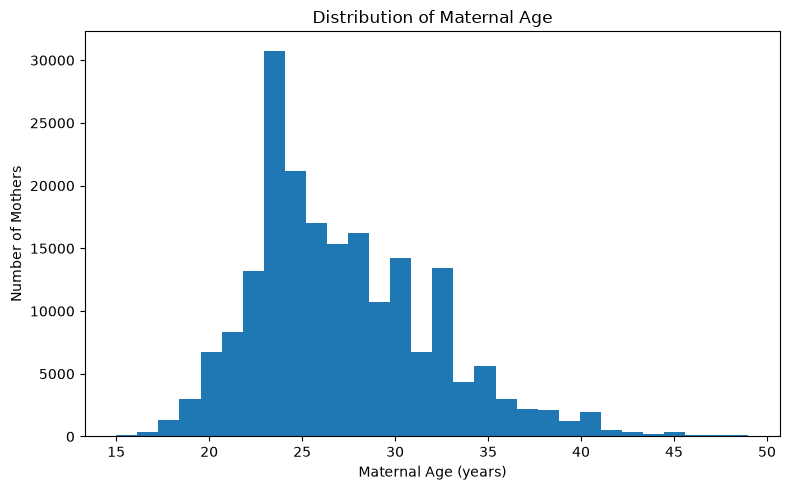

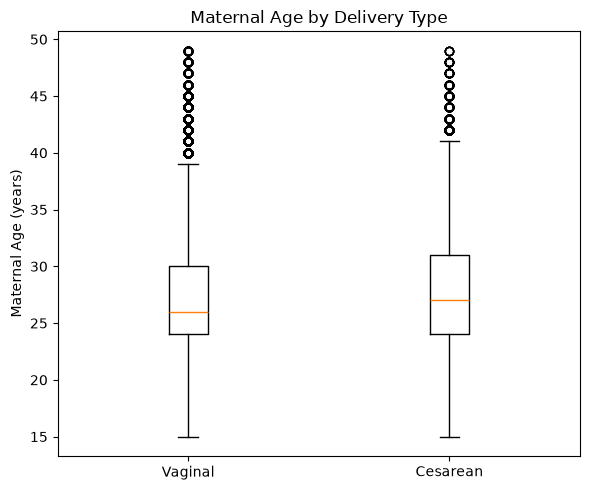

In [11]:
# Analyze maternal age
maternal_age_summary = analyze_numeric_feature(
    data=df_model,
    feature="maternal_age",
    feature_label="Maternal Age",
    x_label="Maternal Age (years)",
    variable_type="continuous"
)

#### Interpretation

The mean maternal age was **27.16 years**. Women with Cesarean deliveries were slightly older than women with vaginal deliveries, with median ages of **27 and 26 years**, respectively.

### 5.2 Body Mass Index

**Why we are doing this:** Maternal BMI is an important indicator of anthropometric and nutritional status and may be associated with delivery method.

**Expected outcome:** The analysis examines the BMI distribution, missing values, and differences between delivery groups.

Maternal BMI summary:


count    195813.000000
mean         21.984591
std           4.056144
min          12.020000
25%          19.170000
50%          21.400000
75%          24.040000
max          59.990000
Name: bmi, dtype: float64

Missing values: 5498 (2.73%)
Maternal BMI by delivery type:


,count,mean,median,std
Vaginal delivery,152512,21.54,21.05,3.74
Cesarean section,43301,23.55,22.93,4.68


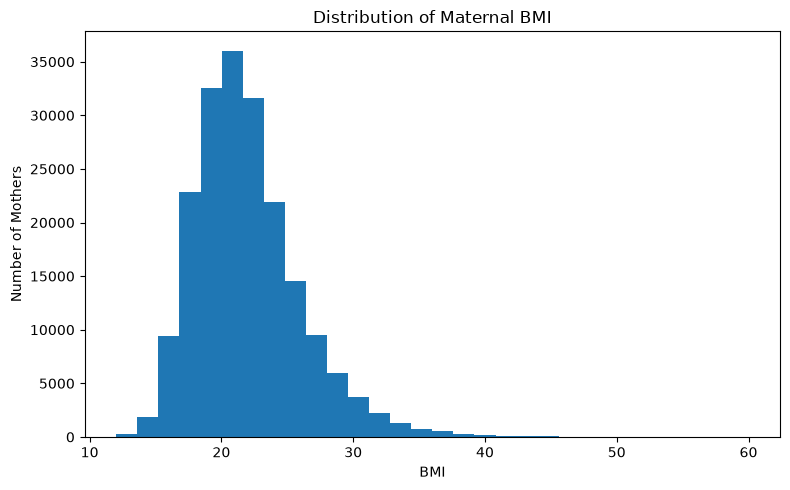

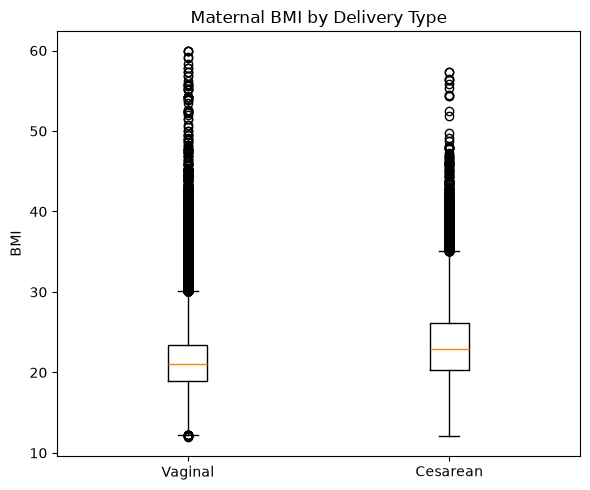

In [12]:
# Analyze maternal BMI
bmi_summary = analyze_numeric_feature(
    data=df_model,
    feature="bmi",
    feature_label="Maternal BMI",
    x_label="BMI",
    variable_type="continuous"
)

#### Interpretation

Women with Cesarean deliveries had a higher mean BMI (**23.55**) than women with vaginal deliveries (**21.54**). BMI was missing for 5,498 observations and will require handling during model preprocessing.

### Maternal Characteristics Summary

Cesarean delivery was associated with slightly older maternal age and a noticeably higher BMI. Both variables will be retained as continuous predictors.

## 6. Socioeconomic Characteristics

### 6.1 Years of Education

**Why we are doing this:** Education may influence healthcare knowledge, access, and utilization.

**Expected outcome:** The analysis compares completed years of education between delivery groups.

Years of Education summary:


count    201311.000000
mean          7.995395
std           5.055247
min           0.000000
25%           5.000000
50%           9.000000
75%          12.000000
max          20.000000
Name: education_years, dtype: float64

Missing values: 0 (0.00%)
Years of Education by delivery type:


,count,mean,median,std
Vaginal delivery,156569,7.39,8.0,4.99
Cesarean section,44742,10.12,10.0,4.71


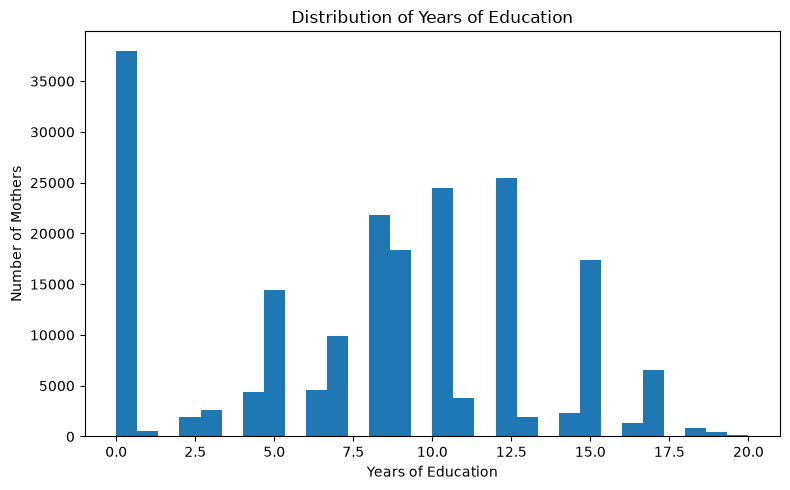

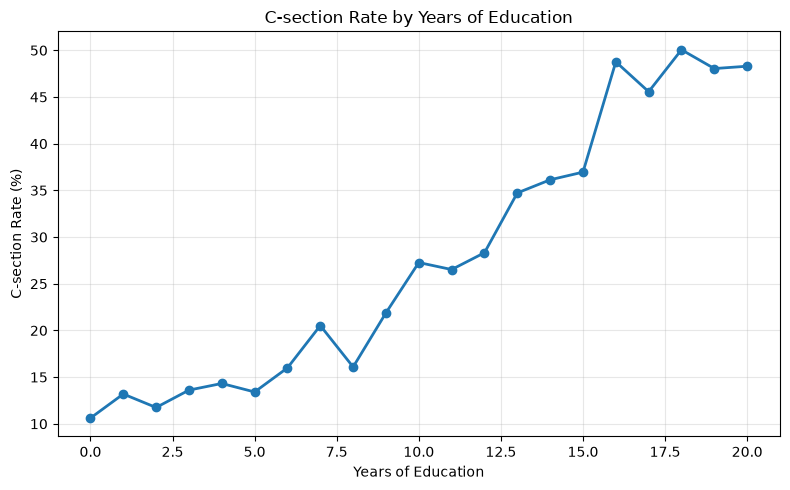

In [13]:
# Analyze years of education
education_summary = analyze_numeric_feature(
    data=df_model,
    feature="education_years",
    feature_label="Years of Education",
    x_label="Years of Education",
    variable_type="ordered"
)

#### Interpretation

Women with Cesarean deliveries had more education on average (**10.12 years**) than women with vaginal deliveries (**7.39 years**).

### 6.2 Wealth Index

**Why we are doing this:** The wealth index represents household socioeconomic status and may influence access to surgical delivery.

**Expected outcome:** The analysis compares C-section rates across the five wealth groups.

Missing values: 0 (0.00%)
Wealth Index summary:


,count,percent,csection_rate
Wealth Index,,,
Poorest,46189,22.94,8.79
Poorer,46414,23.06,15.95
Middle,41341,20.54,24.36
Richer,37251,18.5,31.09
Richest,30116,14.96,38.61


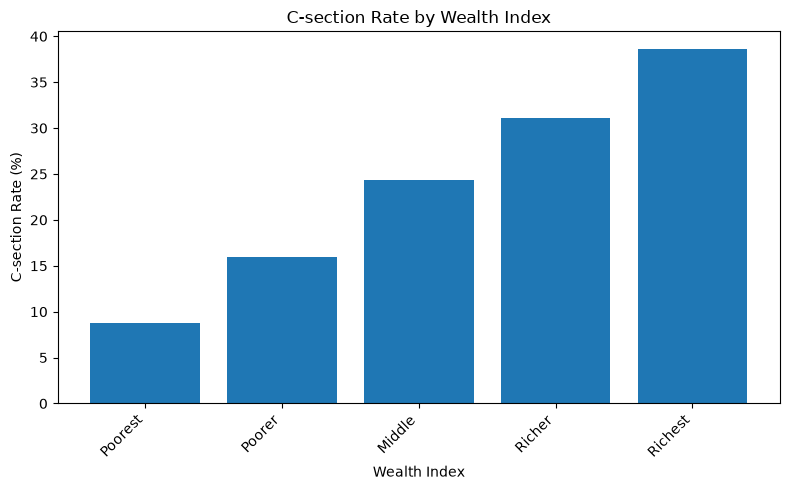

In [14]:
# Analyze the wealth index
wealth_summary = analyze_categorical_feature(
    data=df_model,
    feature="wealth_index",
    feature_label="Wealth Index",
    category_labels=wealth_labels,
    category_order=[
        "Poorest",
        "Poorer",
        "Middle",
        "Richer",
        "Richest"
    ]
)

#### Interpretation

Women with Cesarean deliveries were concentrated in higher wealth groups. The median wealth category was **4** in the Cesarean group and **2** in the vaginal-delivery group.

### 6.3 Place of Residence

**Why we are doing this:** Urban and rural areas differ in healthcare infrastructure and access.

**Expected outcome:** The analysis compares C-section rates between urban and rural women.

Missing values: 0 (0.00%)
Place of Residence summary:


,count,percent,csection_rate
Place of Residence,,,
Urban,44195,21.95,32.9
Rural,157116,78.05,19.22


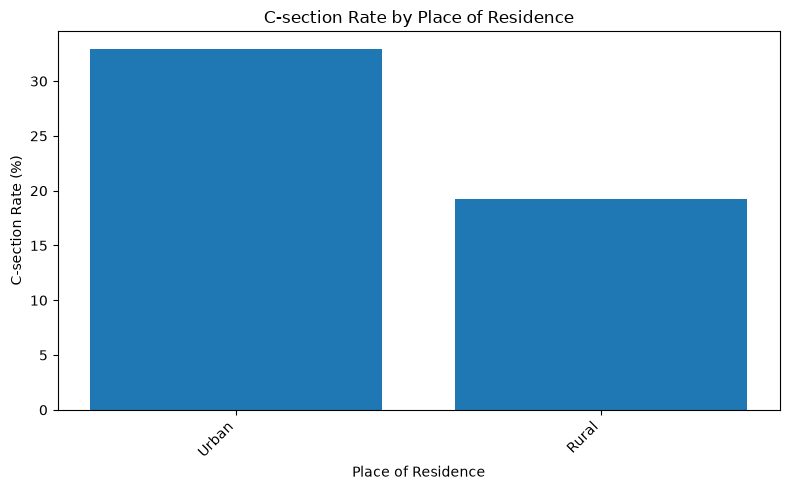

In [15]:
# Analyze place of residence
residence_summary = analyze_categorical_feature(
    data=df_model,
    feature="residence",
    feature_label="Place of Residence",
    category_labels=residence_labels,
    category_order=[
        "Urban",
        "Rural"
    ]
)

#### Interpretation

The C-section rate was **32.90%** among urban women and **19.22%** among rural women.

### 6.4 Religion

**Why we are doing this:** Religion may reflect cultural, geographic, and healthcare-utilization differences.

**Expected outcome:** The analysis compares C-section rates across religious groups and identifies very small categories.

Missing values: 0 (0.00%)
Religion summary:


,count,percent,csection_rate
Religion,,,
Hindu,152579,75.79,21.95
Muslim,28315,14.07,23.59
Christian,12238,6.08,17.71
Sikh,3932,1.95,37.39
Buddhist/Neo-Buddhist,1925,0.96,23.84
Jain,184,0.09,39.67
Jewish,1,0.0,0.0
Parsi/Zoroastrian,10,0.0,10.0
No religion,60,0.03,15.0


Caution: categories with fewer than 100 observations should be interpreted carefully: ['Jewish', 'Parsi/Zoroastrian', 'No religion']


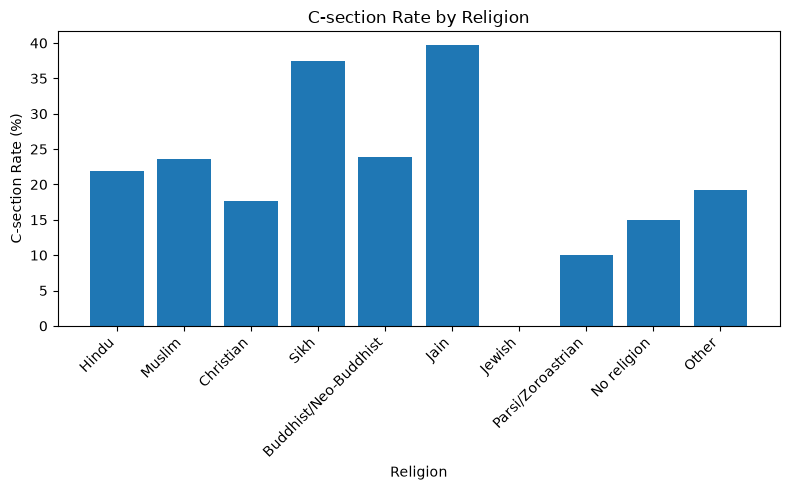

In [16]:
# Analyze religion
religion_summary = analyze_categorical_feature(
    data=df_model,
    feature="religion",
    feature_label="Religion",
    category_labels=religion_labels,
    category_order=[
        "Hindu",
        "Muslim",
        "Christian",
        "Sikh",
        "Buddhist/Neo-Buddhist",
        "Jain",
        "Jewish",
        "Parsi/Zoroastrian",
        "No religion",
        "Other"
    ]
)

#### Interpretation

C-section rates varied across religious groups. Categories containing fewer than 100 observations should be interpreted cautiously, and the observed differences should not be interpreted as causal.

### 6.5 Social Group

**Why we are doing this:** Social group may be associated with socioeconomic position and maternal healthcare access.

**Expected outcome:** The analysis compares C-section rates across Scheduled Caste, Scheduled Tribe, OBC, and other groups.

Missing values: 10552 (5.24%)
Social Group summary:


,count,percent,csection_rate
Social Group,,,
Scheduled Caste,41839,20.78,20.38
Scheduled Tribe,35352,17.56,13.25
Other Backward Class,80077,39.78,23.51
None of these,33491,16.64,30.39
Missing,10552,5.24,23.94


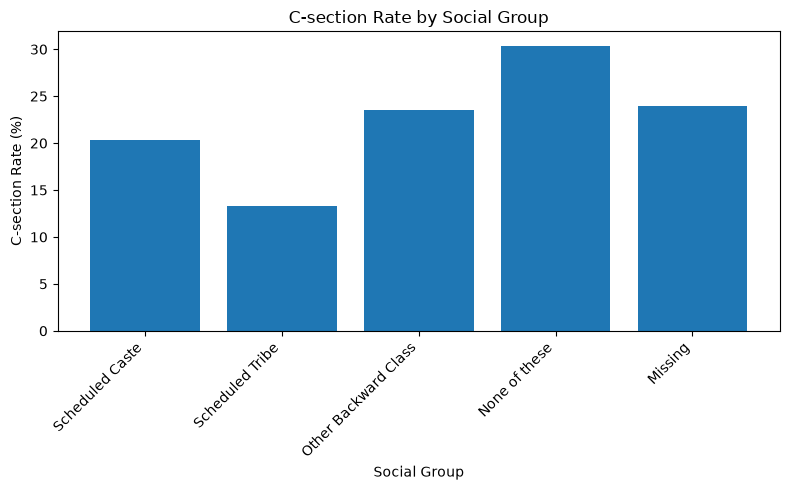

In [17]:
# Analyze social group
social_group_summary = analyze_categorical_feature(
    data=df_model,
    feature="social_group",
    feature_label="Social Group",
    category_labels=social_group_labels,
    category_order=[
        "Scheduled Caste",
        "Scheduled Tribe",
        "Other Backward Class",
        "None of these",
        "Missing"
    ]
)

#### Interpretation

The observed C-section rate was lowest among Scheduled Tribe women (**13.25%**) and highest among women in the "None of these" category (**30.39%**). Social-group information was missing for **5.24%** of records.

### 6.6 Health Insurance Coverage

**Why we are doing this:** Insurance may reduce financial barriers to healthcare services.

**Expected outcome:** The analysis compares C-section rates between insured and uninsured women.

Missing values: 0 (0.00%)
Health Insurance Coverage summary:


,count,percent,csection_rate
Health Insurance Coverage,,,
No,146026,72.54,22.47
Yes,55285,27.46,21.58


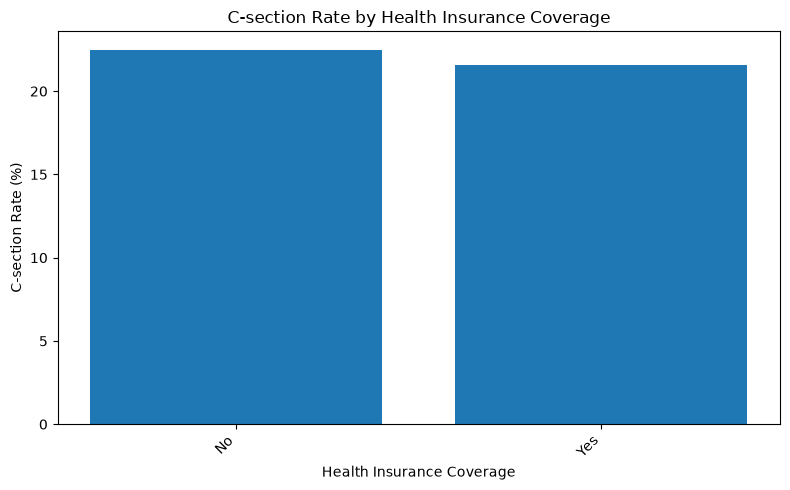

In [18]:
# Analyze health insurance coverage
insurance_summary = analyze_categorical_feature(
    data=df_model,
    feature="health_insurance",
    feature_label="Health Insurance Coverage",
    category_labels=insurance_labels,
    category_order=[
        "No",
        "Yes"
    ]
)

#### Interpretation

The C-section rate was **22.47%** among uninsured women and **21.58%** among insured women. The difference was relatively small.

### Socioeconomic Characteristics Summary

Higher education, greater wealth, and urban residence showed clear associations with Cesarean delivery. Religion and social group also showed differences, although these may be influenced by geography and socioeconomic conditions. Health insurance showed only a small difference.

## 7. Obstetric History

### 7.1 Birth Order

**Why we are doing this:** Birth order represents the position of the current birth in the mother's reproductive history.

**Expected outcome:** The analysis examines how the C-section rate changes across birth order.

Birth Order summary:


count    201311.000000
mean          2.027435
std           1.224486
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          16.000000
Name: birth_order, dtype: float64

Missing values: 0 (0.00%)
Birth Order by delivery type:


,count,mean,median,std
Vaginal delivery,156569,2.12,2.0,1.29
Cesarean section,44742,1.70,2.0,0.90


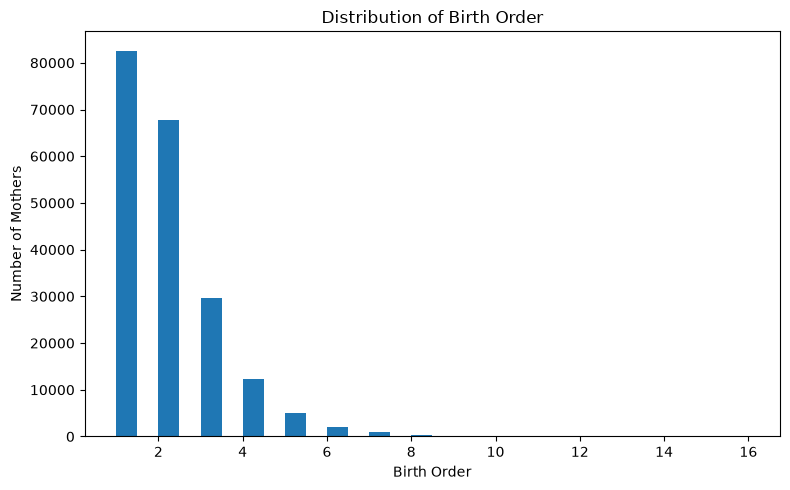

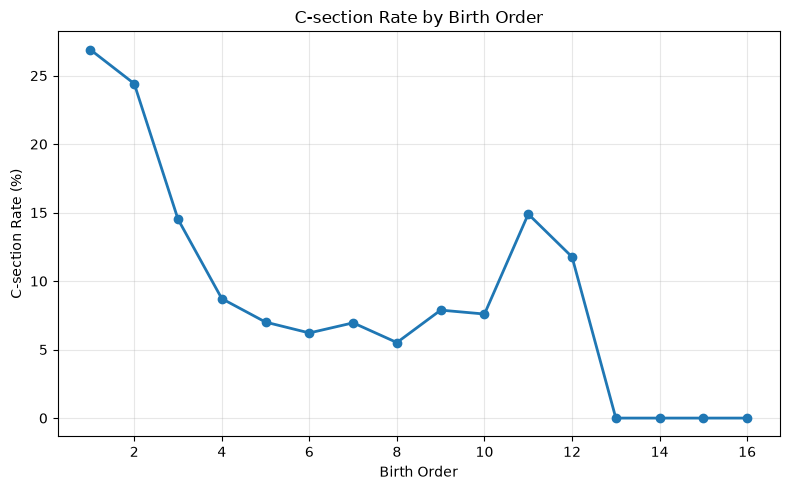

In [19]:
# Analyze birth order
birth_order_summary = analyze_numeric_feature(
    data=df_model,
    feature="birth_order",
    feature_label="Birth Order",
    x_label="Birth Order",
    variable_type="ordered"
)

#### Interpretation

Women with Cesarean deliveries had a lower mean birth order (**1.70**) than women with vaginal deliveries (**2.12**).

### 7.2 Total Children Ever Born

**Why we are doing this:** Total children ever born represents parity and provides a broader measure of reproductive history.

**Expected outcome:** The analysis compares parity between delivery groups.

Total Children Ever Born summary:


count    201311.000000
mean          2.276940
std           1.258449
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          16.000000
Name: total_children_ever_born, dtype: float64

Missing values: 0 (0.00%)
Total Children Ever Born by delivery type:


,count,mean,median,std
Vaginal delivery,156569,2.40,2.0,1.32
Cesarean section,44742,1.86,2.0,0.92


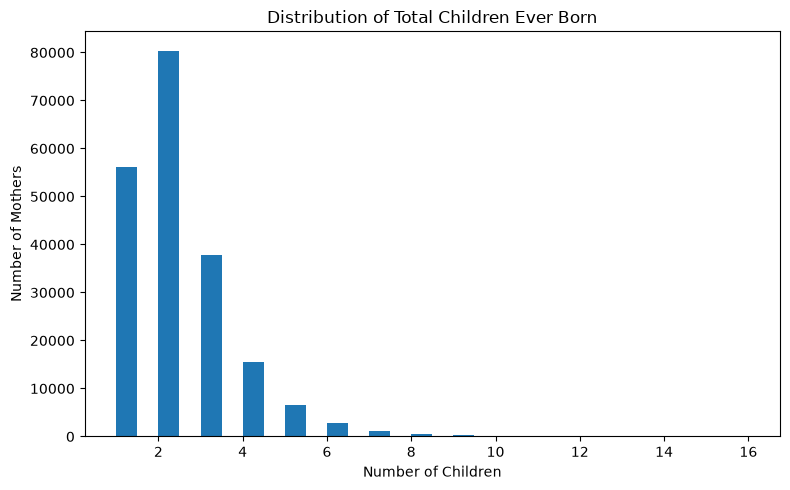

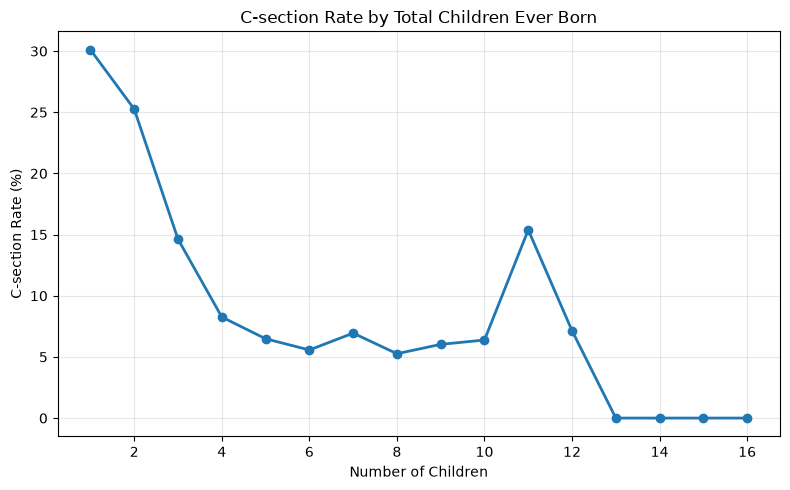

In [20]:
# Analyze total children ever born
children_summary = analyze_numeric_feature(
    data=df_model,
    feature="total_children_ever_born",
    feature_label="Total Children Ever Born",
    x_label="Number of Children",
    variable_type="ordered"
)

#### Interpretation

Women with Cesarean deliveries had fewer children on average (**1.86**) than women with vaginal deliveries (**2.40**).

### 7.3 Preceding Birth Interval

**Why we are doing this:** The preceding birth interval measures the number of months since the previous birth.

**Expected outcome:** The analysis compares birth intervals while documenting structural missingness for first births.

Preceding Birth Interval summary:


count     117970.0
mean     40.153963
std      24.853467
min            6.0
25%           23.0
50%           33.0
75%           50.0
max          280.0
Name: preceding_birth_interval, dtype: Float64

Missing values: 83341 (41.40%)
Note: Missing values are expected for first births because there is no preceding birth interval.
Preceding Birth Interval by delivery type:


,count,mean,median,std
Vaginal delivery,95863,38.8,32.0,23.71
Cesarean section,22107,46.02,38.0,28.58


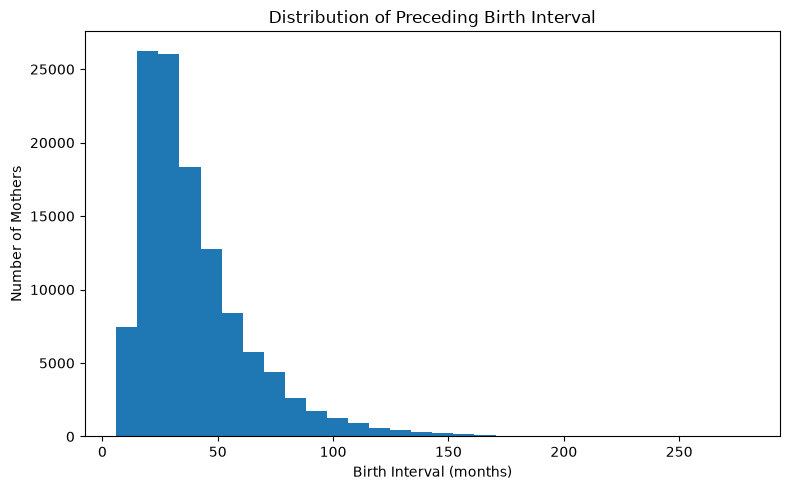

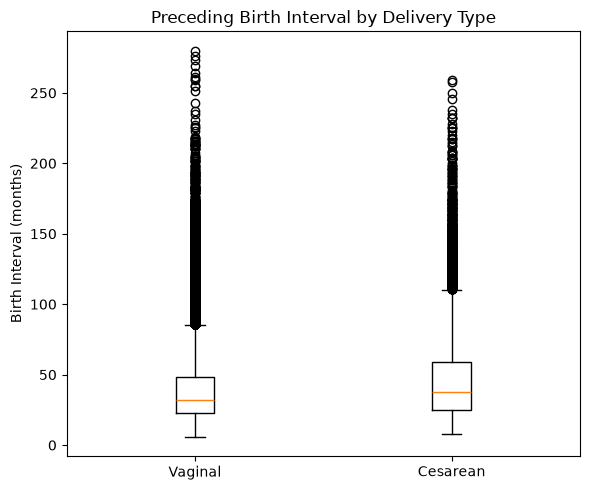

In [21]:
# Analyze the preceding birth interval
birth_interval_summary = analyze_numeric_feature(
    data=df_model,
    feature="preceding_birth_interval",
    feature_label="Preceding Birth Interval",
    x_label="Birth Interval (months)",
    variable_type="continuous",
    structural_missing_note=(
        "Missing values are expected for first births because "
        "there is no preceding birth interval."
    )
)

#### Interpretation

Among women with a previous birth, the median birth interval was **38 months** for Cesarean deliveries and **32 months** for vaginal deliveries. The missing values are expected because this variable does not apply to first births.

### 7.4 Age at First Birth

**Why we are doing this:** Age at first birth may influence maternal and obstetric risk.

**Expected outcome:** The analysis compares age at first birth between delivery groups.

Age at First Birth summary:


count    201311.000000
mean         21.598263
std           3.753053
min           6.000000
25%          19.000000
50%          21.000000
75%          24.000000
max          48.000000
Name: age_at_first_birth, dtype: float64

Missing values: 0 (0.00%)
Age at First Birth by delivery type:


,count,mean,median,std
Vaginal delivery,156569,21.20,21.0,3.51
Cesarean section,44742,22.98,22.0,4.22


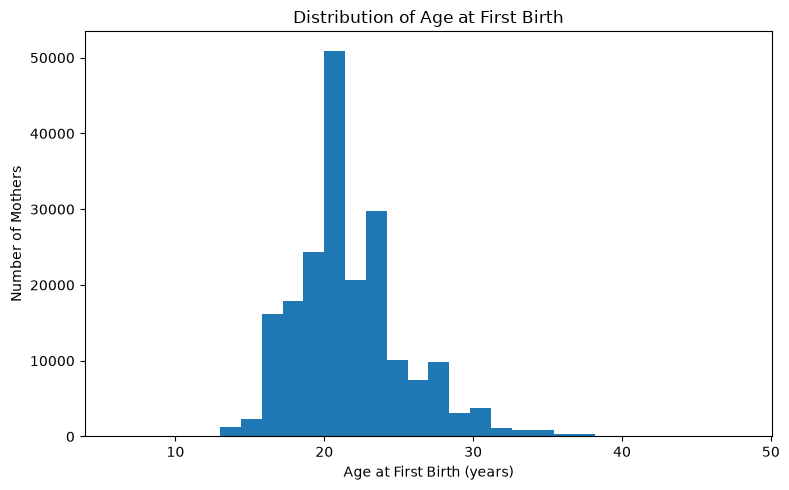

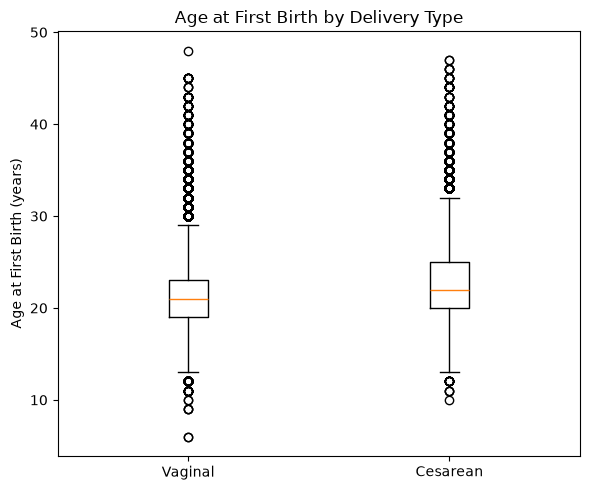

In [22]:
# Analyze age at first birth
first_birth_age_summary = analyze_numeric_feature(
    data=df_model,
    feature="age_at_first_birth",
    feature_label="Age at First Birth",
    x_label="Age at First Birth (years)",
    variable_type="continuous"
)

#### Interpretation

Women with Cesarean deliveries had a higher mean age at first birth (**22.98 years**) than women with vaginal deliveries (**21.20 years**).

### 7.5 Twin Birth

**Why we are doing this:** Multiple pregnancies are more clinically complex and may be associated with Cesarean delivery.

**Expected outcome:** The analysis compares C-section rates between singleton and multiple births.

Missing values: 0 (0.00%)
Twin Birth summary:


,count,percent,csection_rate
Twin Birth,,,
Singleton,197857,98.28,21.88
First twin,1718,0.85,42.03
Second twin,1717,0.85,42.17
Third child in multiple birth,19,0.01,63.16


Caution: categories with fewer than 100 observations should be interpreted carefully: ['Third child in multiple birth']


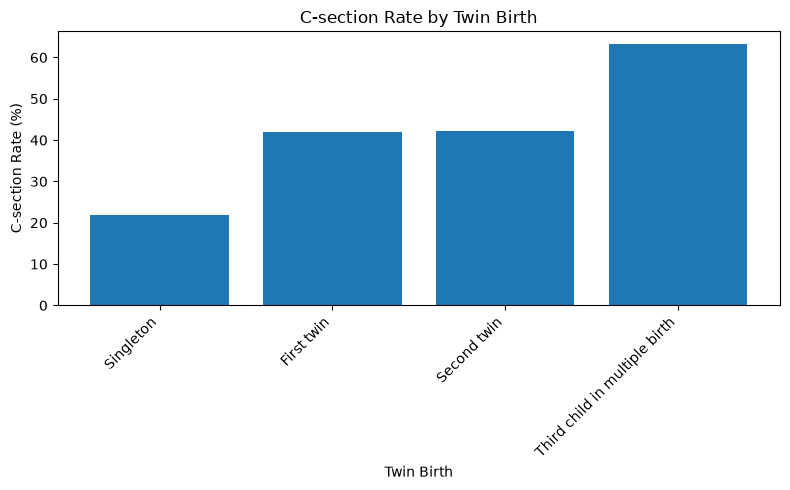

In [23]:
# Analyze twin birth
twin_summary = analyze_categorical_feature(
    data=df_model,
    feature="twin_order",
    feature_label="Twin Birth",
    category_labels=twin_labels,
    category_order=[
        "Singleton",
        "First twin",
        "Second twin",
        "Third child in multiple birth"
    ]
)

#### Interpretation

Singleton births had a C-section rate of **21.88%**, while first and second twin records had rates of approximately **42%**. The third-child multiple-birth category contained only 19 observations and should be interpreted cautiously.

### Obstetric History Summary

Cesarean delivery was more common among earlier births, women with fewer children, women with longer preceding birth intervals, women who began childbearing at older ages, and multiple pregnancies.

## 8. Antenatal Care

### 8.1 Timing of First ANC Visit

**Why we are doing this:** Earlier ANC initiation may reflect healthcare access, pregnancy awareness, and pregnancy risk.

**Expected outcome:** The analysis examines the timing of the first ANC visit and compares it across delivery groups.

Timing of First ANC Visit summary:


count    148453.0
mean     3.374617
std      4.918908
min           0.0
25%           2.0
50%           3.0
75%           3.0
max          98.0
Name: first_anc_timing, dtype: Float64

Missing values: 52858 (26.26%)
Note: Missing values may occur when ANC timing was not recorded or ANC was not received.
Timing of First ANC Visit by delivery type:


,count,mean,median,std
Vaginal delivery,111888,3.43,3.0,4.95
Cesarean section,36565,3.21,3.0,4.83


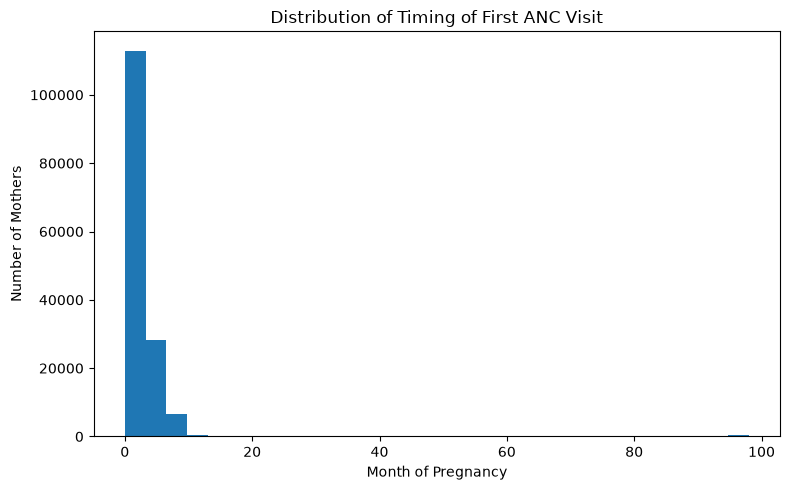

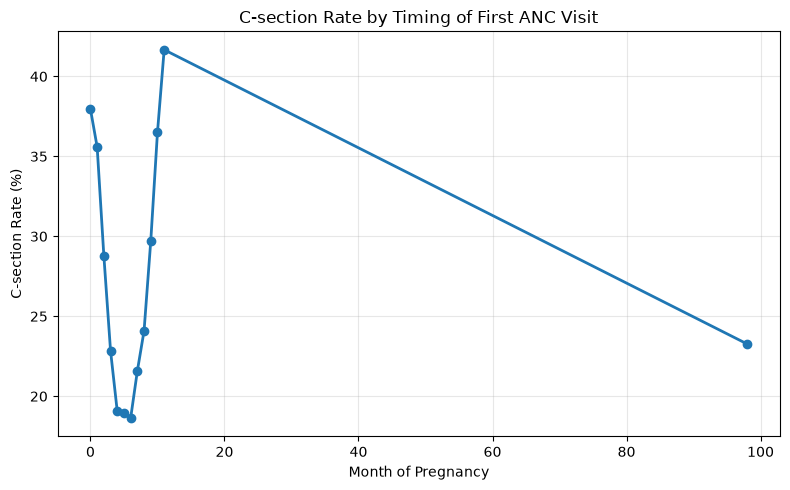

In [24]:
# Analyze the timing of the first ANC visit
first_anc_summary = analyze_numeric_feature(
    data=df_model,
    feature="first_anc_timing",
    feature_label="Timing of First ANC Visit",
    x_label="Month of Pregnancy",
    variable_type="ordered",
    structural_missing_note=(
        "Missing values may occur when ANC timing was not recorded "
        "or ANC was not received."
    )
)

#### Interpretation

The median timing of the first ANC visit was identical in both delivery groups (3 months). Although the Mann–Whitney U test identified a statistically significant difference, the effect size was small, indicating only a modest association between the timing of the first ANC visit and delivery method.

### 8.2 Number of ANC Visits

**Why we are doing this:** The number of ANC visits measures antenatal-care utilization and may reflect healthcare access, monitoring, or pregnancy risk.

**Expected outcome:** The analysis examines how the C-section rate changes as ANC visits increase.

Number of ANC Visits summary:


count    153385.0
mean     5.142993
std      4.535334
min           0.0
25%           3.0
50%           4.0
75%           7.0
max          89.0
Name: anc_visits, dtype: Float64

Missing values: 47926 (23.81%)
Note: Missing values include unrecorded or unknown ANC visit counts.
Number of ANC Visits by delivery type:


,count,mean,median,std
Vaginal delivery,116217,4.8,4.0,4.28
Cesarean section,37168,6.2,5.0,5.12


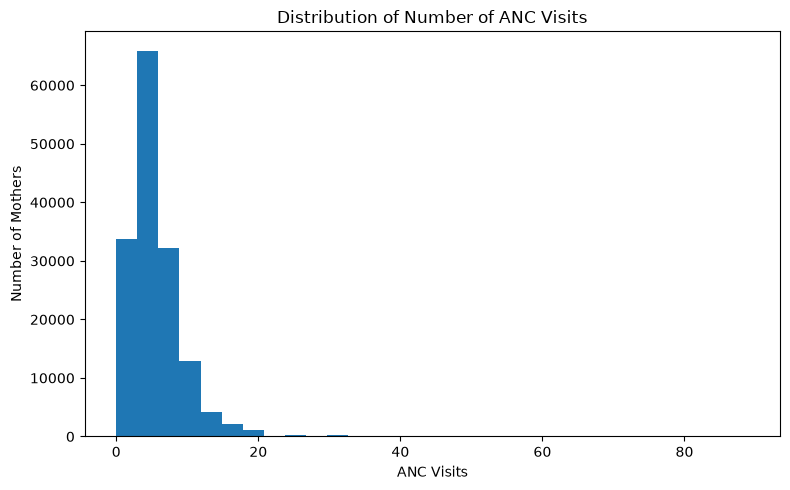

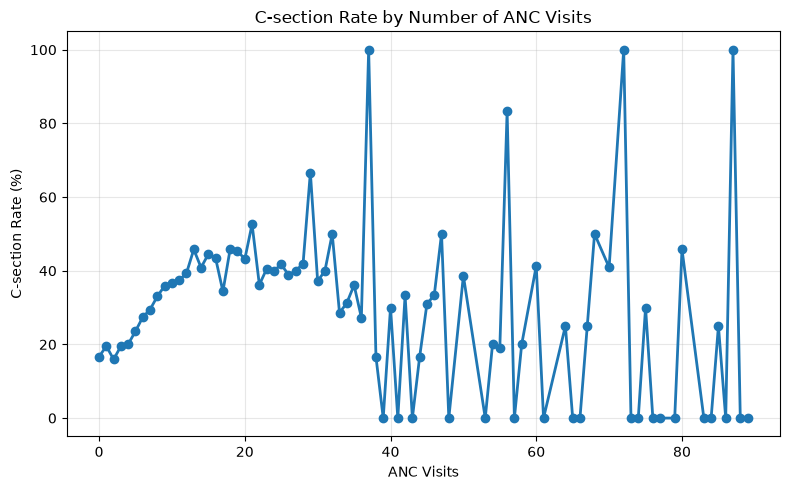

In [25]:
# Analyze the number of ANC visits
anc_visits_summary = analyze_numeric_feature(
    data=df_model,
    feature="anc_visits",
    feature_label="Number of ANC Visits",
    x_label="ANC Visits",
    variable_type="ordered",
    structural_missing_note=(
        "Missing values include unrecorded or unknown ANC visit counts."
    )
)

#### Interpretation

Women with Cesarean deliveries had a higher median number of ANC visits than women with vaginal deliveries (5 vs. 4 visits). Although this difference was statistically significant (rank-biserial effect size = 0.213), the effect size was small, indicating a modest association. Women with more ANC visits may have received closer monitoring because of higher-risk pregnancies or greater healthcare utilization, rather than the number of visits directly influencing the mode of delivery.

### 8.3 ANC Providers

**Why we are doing this:** ANC may be provided by different healthcare workers. Comparing provider types helps identify whether provider access is associated with delivery method.

**Expected outcome:** One table and one chart compare all ANC-provider variables.

ANC Provider summary:


,feature,valid_count,missing_count,yes_count,no_count,csection_rate_yes,csection_rate_no
0,Doctor,155624,45687,99387,56237,29.23,15.49
1,Nurse or midwife,155624,45687,85591,70033,22.11,26.90
2,Traditional attendant,155624,45687,1319,154305,16.76,24.33
3,Community worker,155624,45687,1201,154423,27.81,24.24
4,Anganwadi worker,155624,45687,29820,125804,18.48,25.63
5,ASHA worker,155624,45687,29356,126268,18.21,25.67
6,Other provider,155624,45687,262,155362,30.53,24.25
7,No ANC provider,155624,45687,7171,148453,16.65,24.63


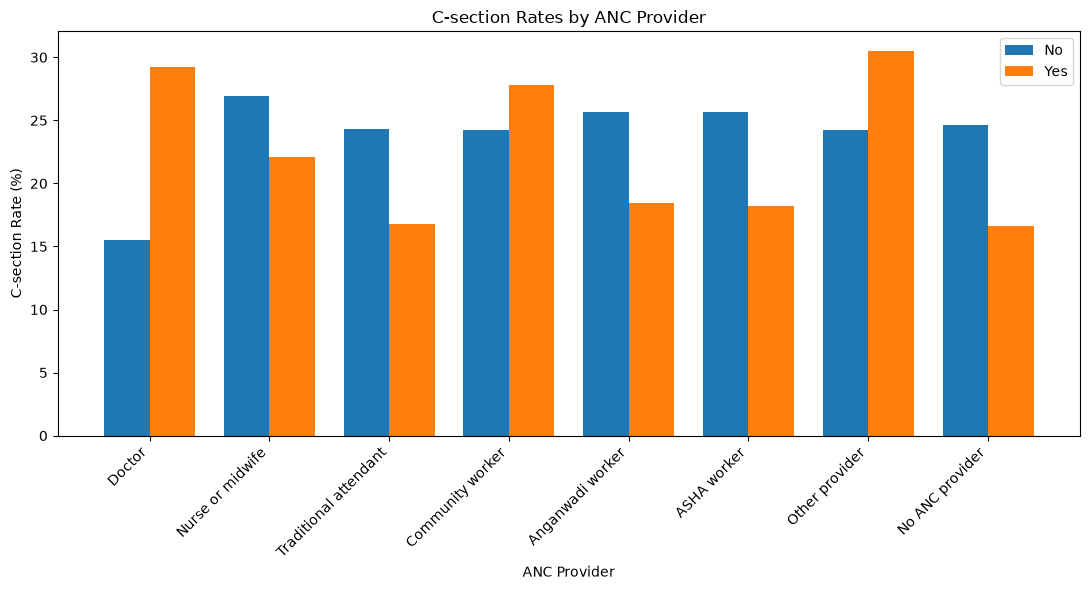

In [26]:
# List the ANC-provider variables
anc_provider_features = [
    "anc_doctor",
    "anc_nurse_midwife",
    "anc_traditional_attendant",
    "anc_community_worker",
    "anc_anganwadi_worker",
    "anc_asha_worker",
    "anc_other_provider",
    "no_anc_provider"
]

# Create readable labels for the provider variables
anc_provider_labels = {
    "anc_doctor": "Doctor",
    "anc_nurse_midwife": "Nurse or midwife",
    "anc_traditional_attendant": "Traditional attendant",
    "anc_community_worker": "Community worker",
    "anc_anganwadi_worker": "Anganwadi worker",
    "anc_asha_worker": "ASHA worker",
    "anc_other_provider": "Other provider",
    "no_anc_provider": "No ANC provider"
}

# Analyze all ANC-provider variables together
anc_provider_summary = analyze_binary_group(
    data=df_model,
    features=anc_provider_features,
    feature_labels=anc_provider_labels,
    group_label="ANC Provider"
)

#### Interpretation

The type of ANC provider was associated with differences in Cesarean section rates. Women who received ANC from a doctor had the highest C-section rate (29.23%), whereas women who did not receive ANC from a doctor had a substantially lower rate (15.49%). In contrast, women who received ANC from Anganwadi workers or ASHA workers had lower C-section rates than those who did not receive care from these providers. These findings likely reflect differences in healthcare access, referral pathways, and pregnancy risk rather than a direct effect of the provider on the mode of delivery.

### 8.4 ANC Quality Indicators

**Why we are doing this:** Routine measurements and tests indicate the completeness of antenatal care.

**Expected outcome:** One table and one chart compare the available ANC-quality indicators.

ANC Quality Indicator summary:


,feature,valid_count,missing_count,yes_count,no_count,csection_rate_yes,csection_rate_no
0,Weight measured,148453,52858,145477,2976,24.85,13.78
1,Blood pressure measured,148453,52858,144601,3852,25.01,10.51
2,Urine sample taken,148453,52858,141161,7292,25.30,11.74
3,Blood sample taken,148453,52858,142158,6295,25.27,10.14
4,Told about complications,148453,52858,117269,31184,24.96,23.38


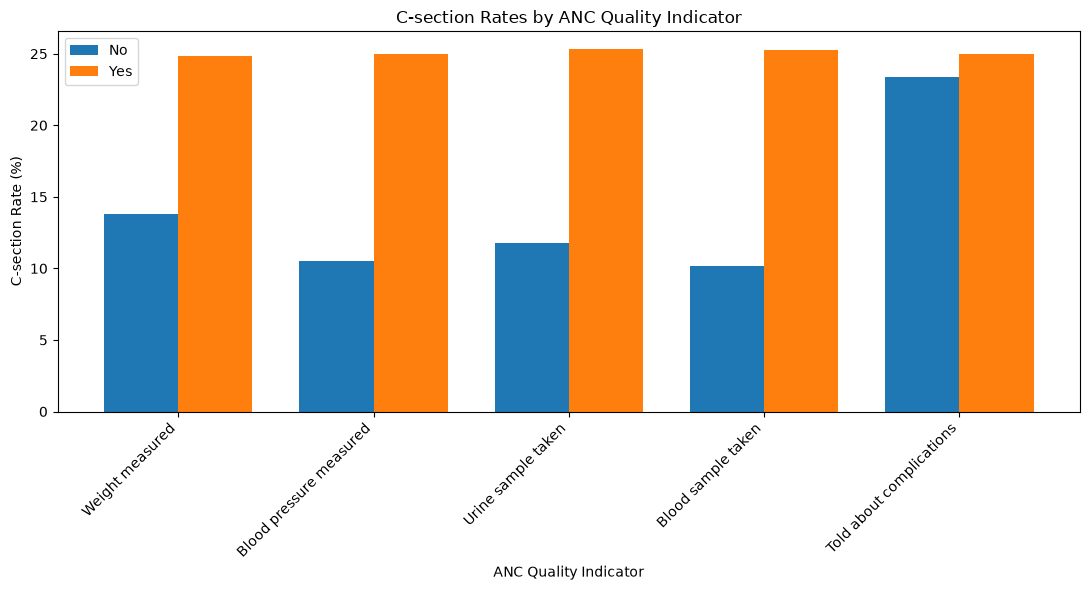

In [27]:
# List the ANC-quality variables
anc_quality_features = [
    "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy",
    "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications"
]

# Create readable labels
anc_quality_labels = {
    "weight_measured_during_pregnancy": "Weight measured",
    "bp_measured_during_pregnancy": "Blood pressure measured",
    "urine_sample_during_pregnancy": "Urine sample taken",
    "blood_sample_during_pregnancy": "Blood sample taken",
    "told_about_pregnancy_complications": "Told about complications"
}

# Analyze the ANC-quality variables together
anc_quality_summary = analyze_binary_group(
    data=df_model,
    features=anc_quality_features,
    feature_labels=anc_quality_labels,
    group_label="ANC Quality Indicator"
)

#### Interpretation

Women who received routine ANC services, including weight measurement, blood pressure measurement, urine testing, and blood testing, had higher C-section rates than women who did not receive these services. However, the effect sizes for these associations were negligible, despite being statistically significant. These findings are likely to reflect differences in healthcare access, quality of antenatal care, and closer monitoring of higher-risk pregnancies rather than a direct effect of these ANC services on the mode of delivery.

### 8.5 Counselling About Pregnancy Danger Signs

**Why we are doing this:** Counselling reflects the educational and preventive component of ANC.

**Expected outcome:** One table and one chart compare all counselling variables.

Pregnancy Danger-Sign Counselling summary:


,feature,valid_count,missing_count,yes_count,no_count,csection_rate_yes,csection_rate_no
0,Vaginal bleeding,153794,47517,98302,55492,24.81,23.24
1,Convulsions,153794,47517,97155,56639,24.42,23.93
2,Prolonged labour,153794,47517,104905,48889,24.32,24.07
3,Severe abdominal pain,153794,47517,107197,46597,24.42,23.83
4,High blood pressure,153794,47517,107913,45881,24.47,23.70


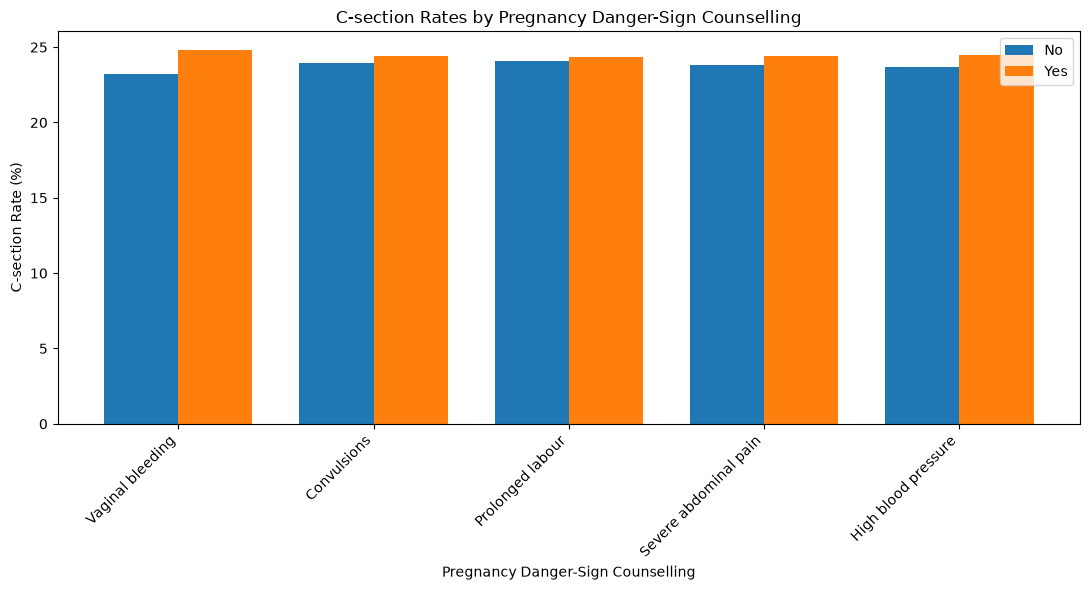

In [28]:
# List the counselling variables
counselling_features = [
    "counselled_vaginal_bleeding",
    "counselled_convulsions",
    "counselled_prolonged_labour",
    "counselled_severe_abdominal_pain",
    "counselled_high_blood_pressure"
]

# Create readable labels
counselling_labels = {
    "counselled_vaginal_bleeding": "Vaginal bleeding",
    "counselled_convulsions": "Convulsions",
    "counselled_prolonged_labour": "Prolonged labour",
    "counselled_severe_abdominal_pain": "Severe abdominal pain",
    "counselled_high_blood_pressure": "High blood pressure"
}

# Analyze all counselling variables together
counselling_summary = analyze_binary_group(
    data=df_model,
    features=counselling_features,
    feature_labels=counselling_labels,
    group_label="Pregnancy Danger-Sign Counselling"
)

#### Interpretation

The C-section rates were broadly similar between women who did and did not receive counselling on pregnancy danger signs, including vaginal bleeding, convulsions, prolonged labour, severe abdominal pain, and high blood pressure. Although some counselling variables were statistically significant, all associations had negligible effect sizes, indicating limited practical differences between the delivery groups. These findings suggest that counselling alone was not strongly associated with the mode of delivery and may primarily reflect routine antenatal care practices.

### Antenatal Care Summary

Women with Cesarean deliveries generally had a higher number of ANC visits and were more likely to receive ANC from a doctor and undergo routine antenatal assessments such as weight measurement, blood pressure measurement, urine testing, and blood testing. In contrast, the timing of the first ANC visit showed only a modest association with delivery type, while counselling on pregnancy danger signs showed minimal practical differences between the delivery groups. Overall, the observed associations likely reflect differences in healthcare access, quality of antenatal care, and closer monitoring of higher-risk pregnancies rather than a direct effect of ANC on the mode of delivery.

## 9. Pregnancy Complications

### 9.1 Convulsions During Pregnancy

**Why we are doing this:** Convulsions may indicate a serious pregnancy complication and could increase the need for surgical delivery.

**Expected outcome:** The analysis compares C-section rates between women with and without reported convulsions.

Missing values: 40252 (19.99%)
Convulsions During Pregnancy summary:


,count,percent,csection_rate
Convulsions During Pregnancy,,,
No,136764,67.94,23.91
Yes,24295,12.07,23.74
Missing,40252,19.99,15.58


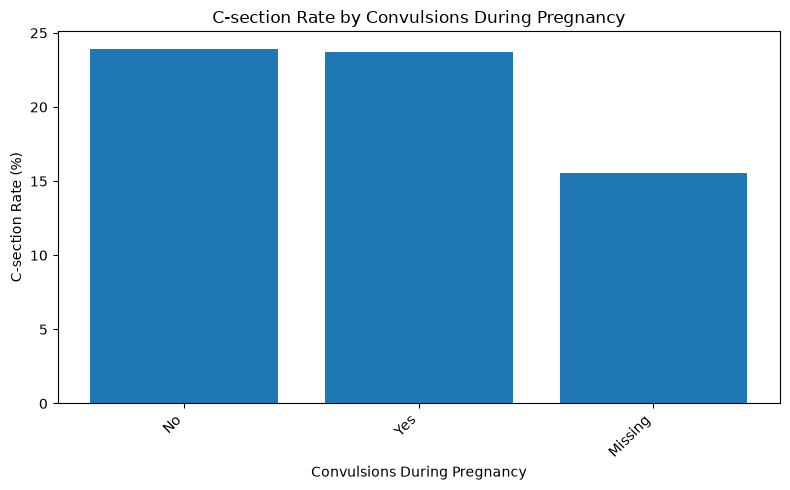

In [29]:
# Analyze convulsions during pregnancy
convulsions_summary = analyze_categorical_feature(
    data=df_model,
    feature="convulsions_during_pregnancy",
    feature_label="Convulsions During Pregnancy",
    category_labels=yes_no_labels,
    category_order=[
        "No",
        "Yes",
        "Missing"
    ]
)

#### Interpretation

The C-section rate was similar among women who reported convulsions during pregnancy (23.74%) and those who did not (23.91%). The association was not statistically significant and the effect size was negligible (Cramer's V ≈ 0.000), indicating that reported convulsions were not meaningfully associated with the mode of delivery in this dataset. Nearly 20% of observations had missing information for this variable and should be handled appropriately during preprocessing.

### 9.2 Swelling During Pregnancy

**Why we are doing this:** Swelling may be associated with hypertensive disorders or other pregnancy complications.

**Expected outcome:** The analysis compares C-section rates between women with and without reported swelling.

Missing values: 40214 (19.98%)
Swelling During Pregnancy summary:


,count,percent,csection_rate
Swelling During Pregnancy,,,
No,110580,54.93,21.91
Yes,50517,25.09,28.21
Missing,40214,19.98,15.57


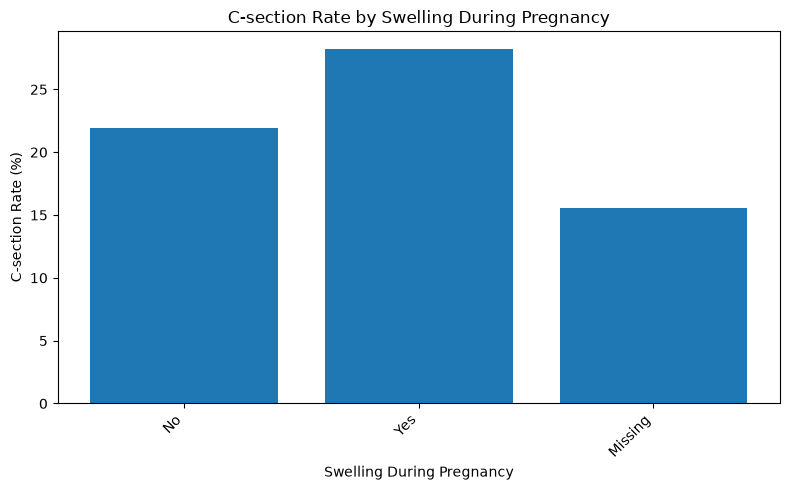

In [30]:
# Analyze swelling during pregnancy
swelling_summary = analyze_categorical_feature(
    data=df_model,
    feature="swelling_during_pregnancy",
    feature_label="Swelling During Pregnancy",
    category_labels=yes_no_labels,
    category_order=[
        "No",
        "Yes",
        "Missing"
    ]
)

#### Interpretation

Women who reported swelling during pregnancy had a higher C-section rate (28.21%) than women who did not report swelling (21.91%). Although this association was statistically significant, the effect size was negligible (Cramer's V = 0.069), indicating that the practical association was modest. Swelling may reflect underlying pregnancy complications requiring closer clinical management rather than directly influencing the mode of delivery.

### Pregnancy Complications Summary

Among the pregnancy complications examined, swelling during pregnancy was associated with a higher C-section rate, whereas reported convulsions showed little difference between delivery groups. Overall, these variables demonstrated weak associations with delivery method and should be interpreted as indicators of pregnancy risk rather than direct determinants of Cesarean section delivery.

## 10. Facility Characteristics

### 10.1 Facility Type

**Why we are doing this:** Public, private, and other facilities may differ in case mix, resources, referral patterns, and Cesarean-delivery practices.

**Expected outcome:** The analysis compares C-section rates across facility types.

Missing values: 0 (0.00%)
Facility Type summary:


,count,percent,csection_rate
Facility Type,,,
other,517,0.26,0.0
private,50495,25.08,47.08
public,150299,74.66,13.95


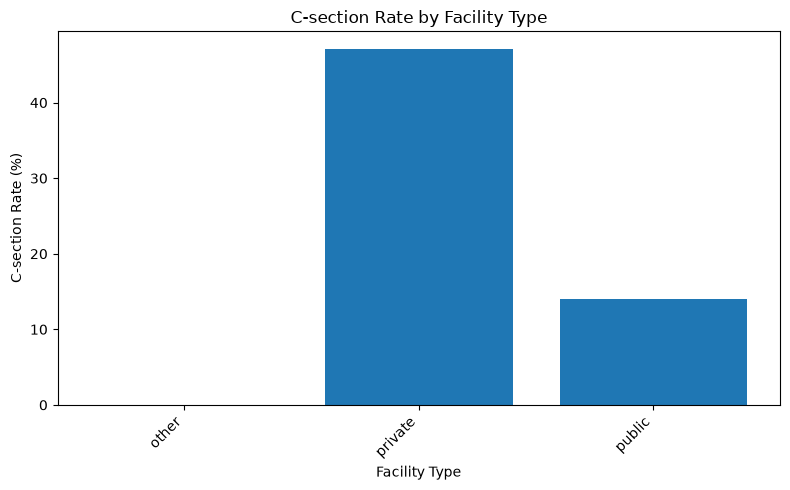

In [31]:
# Analyze facility type
facility_summary = analyze_categorical_feature(
    data=df_model,
    feature="facility_type",
    feature_label="Facility Type"
)

#### Interpretation

Facility type showed the strongest association with delivery method among all categorical variables. The C-section rate was substantially higher in private facilities (47.08%) than in public facilities (13.95%). This difference may reflect variations in patient case mix, referral patterns, healthcare practices, and access to obstetric services rather than a direct effect of the facility itself.

### Facility Characteristics Summary

Facility type showed the strongest association with Cesarean section delivery among all categorical variables examined in the EDA (Cramer's V = 0.346, moderate effect). The C-section rate was substantially higher in private facilities (47.08%) than in public facilities (13.95%), while very few deliveries occurred in the "other" facility category. These findings suggest that the type of healthcare facility is an important factor associated with delivery method, although the observed differences may also reflect variations in patient case mix, referral patterns, and clinical practices rather than a direct effect of the facility itself.

## 11. Statistical Comparison of Numeric Variables

The Mann-Whitney U test compares numeric-variable distributions between vaginal and Cesarean deliveries. Rank-biserial correlation is included because the large sample size can make small differences statistically significant.

In [32]:
# List the numeric variables analyzed in the EDA
completed_numeric_features = [
    "maternal_age",
    "bmi",
    "education_years",
    "birth_order",
    "total_children_ever_born",
    "preceding_birth_interval",
    "age_at_first_birth",
    "first_anc_timing",
    "anc_visits"
]

# Run the comparison for every numeric variable
numeric_test_results = [
    compare_numeric_feature(df_model, feature)
    for feature in completed_numeric_features
]

# Convert the results into a dataframe
numeric_test_summary = pd.DataFrame(numeric_test_results)

# Round the readable values
numeric_test_summary[
    [
        "vaginal_median",
        "csection_median",
        "median_difference",
        "rank_biserial_effect"
    ]
] = numeric_test_summary[
    [
        "vaginal_median",
        "csection_median",
        "median_difference",
        "rank_biserial_effect"
    ]
].round(3)

# Display the statistical comparison table
display(numeric_test_summary)

,feature,vaginal_n,csection_n,vaginal_median,csection_median,median_difference,u_statistic,p_value,rank_biserial_effect,effect_magnitude
0,maternal_age,156569,44742,26.00,27.00,1.00,3.150445e+09,1.419885e-232,0.101,Small
1,bmi,152512,43301,21.05,22.93,1.88,2.422217e+09,0.000000e+00,0.266,Small
2,education_years,156569,44742,8.00,10.00,2.00,2.401544e+09,0.000000e+00,0.314,Moderate
3,birth_order,156569,44742,2.00,2.00,0.00,4.130485e+09,0.000000e+00,-0.179,Small
4,total_children_ever_born,156569,44742,2.00,2.00,0.00,4.341694e+09,0.000000e+00,-0.240,Small
5,preceding_birth_interval,95863,22107,32.00,38.00,6.00,8.930828e+08,1.435124e-291,0.157,Small
6,age_at_first_birth,156569,44742,21.00,22.00,1.00,2.604287e+09,0.000000e+00,0.256,Small
7,first_anc_timing,111888,36565,3.00,3.00,0.00,2.277059e+09,1.170549e-259,-0.113,Small
8,anc_visits,116217,37168,4.00,5.00,1.00,1.700259e+09,0.000000e+00,0.213,Small


## 12. Statistical Comparison of Categorical Variables

Chi-square tests assess whether each categorical variable is associated with delivery type. Cramer's V describes the strength of each association.

In [33]:
# List the categorical and binary variables analyzed in the EDA
completed_categorical_features = [
    "wealth_index",
    "residence",
    "religion",
    "social_group",
    "health_insurance",
    "twin_order",
    "anc_doctor",
    "anc_nurse_midwife",
    "anc_traditional_attendant",
    "anc_community_worker",
    "anc_anganwadi_worker",
    "anc_asha_worker",
    "anc_other_provider",
    "no_anc_provider",
    "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy",
    "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications",
    "counselled_vaginal_bleeding",
    "counselled_convulsions",
    "counselled_prolonged_labour",
    "counselled_severe_abdominal_pain",
    "counselled_high_blood_pressure",
    "convulsions_during_pregnancy",
    "swelling_during_pregnancy",
    "facility_type"
]

# Run the comparison for every categorical variable
categorical_test_results = [
    compare_categorical_feature(df_model, feature)
    for feature in completed_categorical_features
]

# Convert the results into a dataframe
categorical_test_summary = pd.DataFrame(
    categorical_test_results
)

# Round the readable values
categorical_test_summary[
    ["chi_square", "cramers_v"]
] = categorical_test_summary[
    ["chi_square", "cramers_v"]
].round(3)

# Display the statistical comparison table
display(categorical_test_summary)

,feature,complete_n,chi_square,p_value,cramers_v,effect_magnitude
0,wealth_index,201311,12360.290,0.000000e+00,0.248,Small
1,residence,201311,3730.264,0.000000e+00,0.136,Small
2,religion,201311,753.642,2.011914e-156,0.061,Negligible
3,social_group,190759,3107.520,0.000000e+00,0.128,Small
4,health_insurance,201311,18.054,2.147341e-05,0.009,Negligible
5,twin_order,201311,816.999,8.903480e-177,0.064,Negligible
6,anc_doctor,155624,3684.591,0.000000e+00,0.154,Small
7,anc_nurse_midwife,155624,481.152,1.199754e-106,0.056,Negligible
8,anc_traditional_attendant,155624,40.395,2.075105e-10,0.016,Negligible
9,anc_community_worker,155624,8.094,4.440894e-03,0.007,Negligible


## 13. Correlation and Redundancy Analysis

Spearman correlation is examined among numeric and binary predictors. This helps identify variables that may provide overlapping information.

Correlation does not imply causation and does not fully describe relationships involving nominal categorical variables.

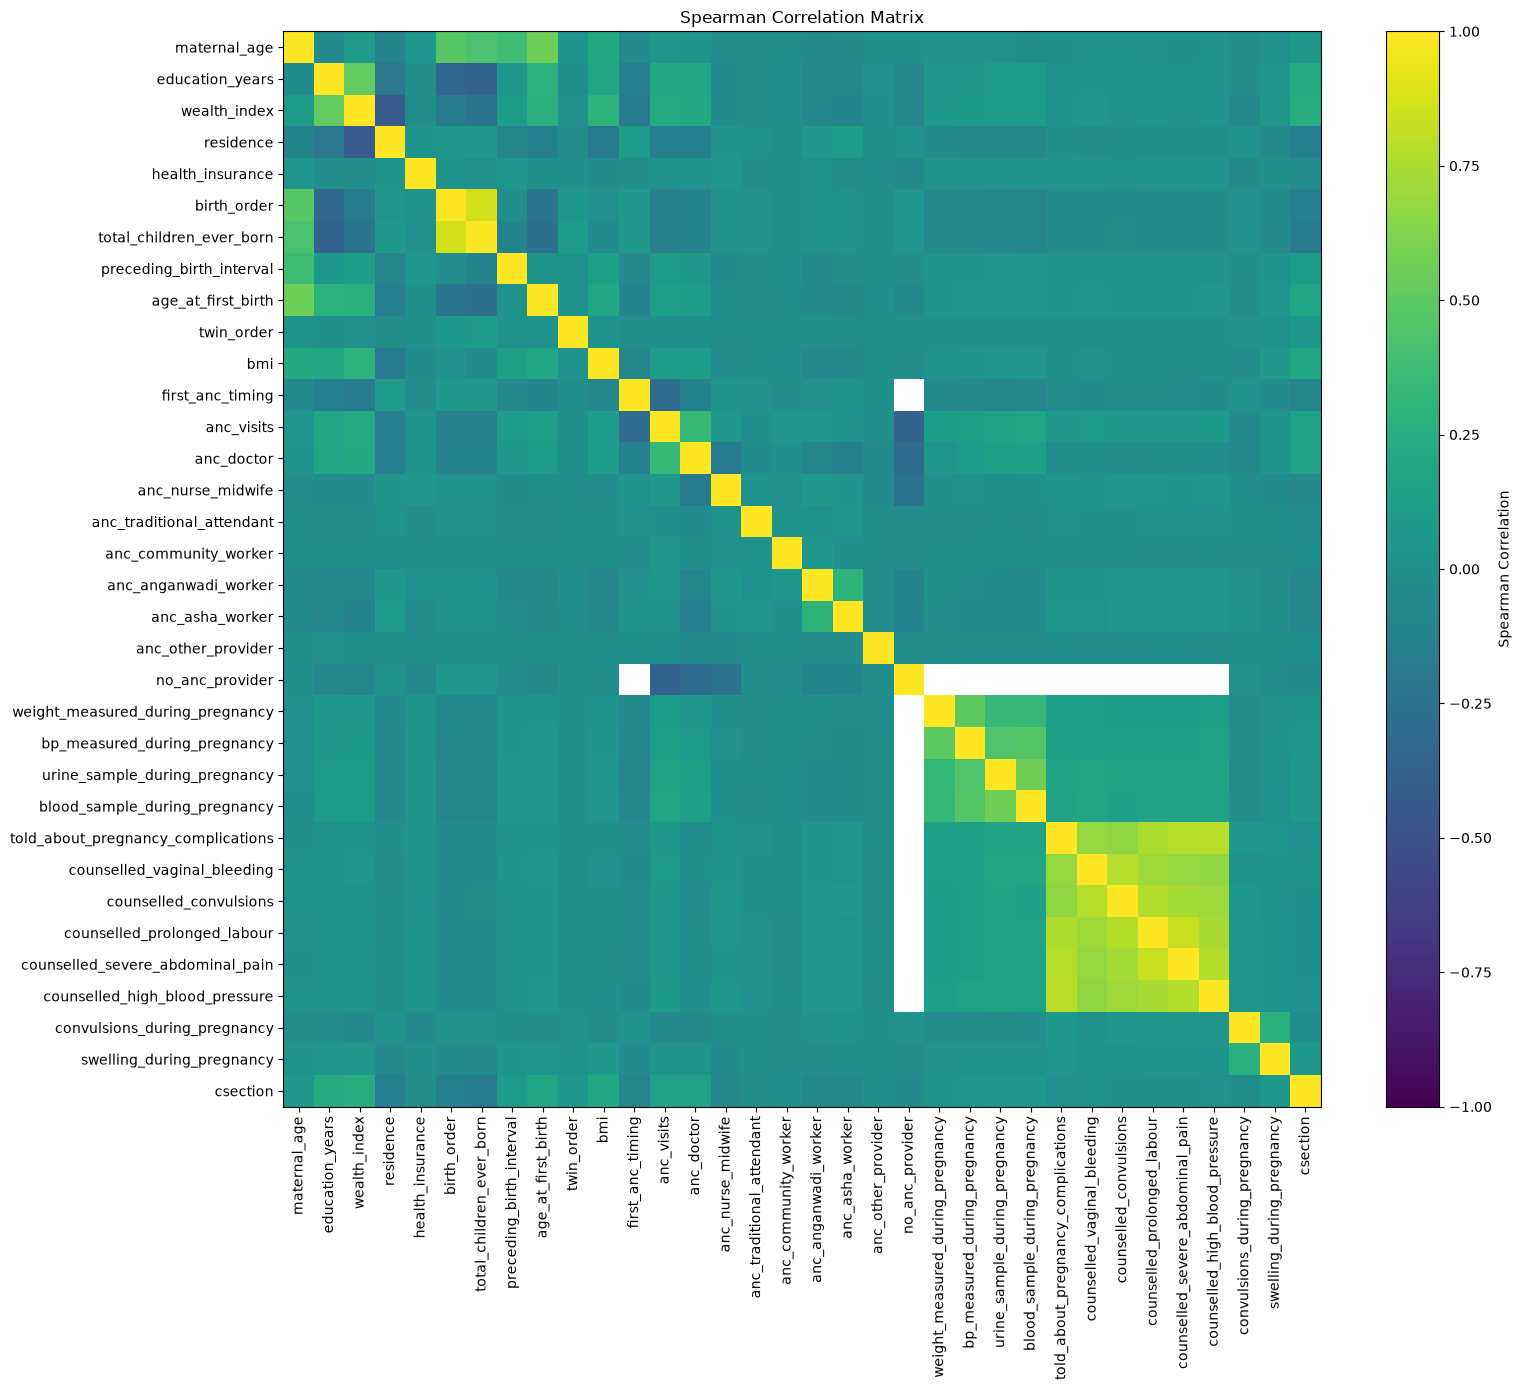

In [34]:
# Select numeric and binary predictors
correlation_features = [
    "maternal_age",
    "education_years",
    "wealth_index",
    "residence",
    "health_insurance",
    "birth_order",
    "total_children_ever_born",
    "preceding_birth_interval",
    "age_at_first_birth",
    "twin_order",
    "bmi",
    "first_anc_timing",
    "anc_visits",
    "anc_doctor",
    "anc_nurse_midwife",
    "anc_traditional_attendant",
    "anc_community_worker",
    "anc_anganwadi_worker",
    "anc_asha_worker",
    "anc_other_provider",
    "no_anc_provider",
    "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy",
    "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications",
    "counselled_vaginal_bleeding",
    "counselled_convulsions",
    "counselled_prolonged_labour",
    "counselled_severe_abdominal_pain",
    "counselled_high_blood_pressure",
    "convulsions_during_pregnancy",
    "swelling_during_pregnancy",
    "csection"
]

# Convert the selected variables to numeric values
correlation_data = (
    df_model[correlation_features]
    .apply(pd.to_numeric, errors="coerce")
)

# Calculate the Spearman correlation matrix
correlation_matrix = correlation_data.corr(
    method="spearman"
)

# Plot the complete correlation matrix
plt.figure(figsize=(16, 14))
plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Spearman Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [35]:
# Find highly correlated predictor pairs
high_correlation_pairs = []

for first_index in range(len(correlation_matrix.columns)):
    for second_index in range(first_index + 1, len(correlation_matrix.columns)):
        first_feature = correlation_matrix.columns[first_index]
        second_feature = correlation_matrix.columns[second_index]

        # Exclude pairs involving the target
        if "csection" in (first_feature, second_feature):
            continue

        correlation_value = correlation_matrix.iloc[
            first_index,
            second_index
        ]

        if abs(correlation_value) >= 0.70:
            high_correlation_pairs.append({
                "feature_1": first_feature,
                "feature_2": second_feature,
                "spearman_correlation": correlation_value
            })

# Convert the results into a dataframe
high_correlation_summary = pd.DataFrame(
    high_correlation_pairs
)

# Display the highly correlated pairs
if high_correlation_summary.empty:
    print("No predictor pairs had an absolute correlation of 0.70 or higher.")
else:
    high_correlation_summary["spearman_correlation"] = (
        high_correlation_summary["spearman_correlation"].round(3)
    )
    display(high_correlation_summary)

,feature_1,feature_2,spearman_correlation
0,birth_order,total_children_ever_born,0.866
1,told_about_pregnancy_complications,counselled_prolonged_labour,0.752
2,told_about_pregnancy_complications,counselled_severe_abdominal_pain,0.779
3,told_about_pregnancy_complications,counselled_high_blood_pressure,0.787
4,counselled_vaginal_bleeding,counselled_convulsions,0.776
5,counselled_vaginal_bleeding,counselled_prolonged_labour,0.712
6,counselled_convulsions,counselled_prolonged_labour,0.767
7,counselled_convulsions,counselled_severe_abdominal_pain,0.730
8,counselled_convulsions,counselled_high_blood_pressure,0.708
9,counselled_prolonged_labour,counselled_severe_abdominal_pain,0.828


### Interpretation

Several predictor pairs showed high positive correlations, indicating potential redundancy within the dataset. The strongest correlation was observed between **birth order** and **total children ever born** (Spearman's ρ = 0.866), suggesting that these variables capture closely related aspects of a woman's reproductive history. Strong correlations were also observed among the pregnancy danger-sign counselling variables, indicating that women who received counselling on one danger sign were often counselled on others as part of routine antenatal care. These findings will be considered during feature selection and model development to minimize redundancy while retaining clinically relevant information. However, correlation alone is not sufficient justification for removing a variable, and the final selection will also consider clinical relevance and model performance.

## 14. Missing-Value Analysis

Missingness is summarized for every predictor. Some missingness is structural, while other missing values may require imputation or a missing category during preprocessing.

In [36]:
# Exclude identifiers, survey-design variables, and the target
missingness_exclusions = [
    "respondent_id",
    "cluster_number",
    "household_number",
    "respondent_line_number",
    "sample_weight",
    "survey_weight",
    "primary_sampling_unit",
    "sample_stratum_v022",
    "sample_stratum_v023",
    "csection"
]

# Select the predictor columns
missingness_features = [
    column
    for column in df_model.columns
    if column not in missingness_exclusions
]

# Calculate missing-value counts and percentages
missing_summary = pd.DataFrame({
    "missing_count": (
        df_model[missingness_features]
        .isna()
        .sum()
    ),
    "missing_percent": (
        df_model[missingness_features]
        .isna()
        .mean()
        .mul(100)
    )
})

# Keep variables with at least one missing value
missing_summary = (
    missing_summary
    .loc[missing_summary["missing_count"] > 0]
    .sort_values(
        "missing_percent",
        ascending=False
    )
)

# Round the percentages
missing_summary["missing_percent"] = (
    missing_summary["missing_percent"].round(2)
)

# Display the missing-value table
display(missing_summary)

,missing_count,missing_percent
preceding_birth_interval,83341,41.40
first_anc_timing,52858,26.26
bp_measured_during_pregnancy,52858,26.26
urine_sample_during_pregnancy,52858,26.26
told_about_pregnancy_complications,52858,26.26
weight_measured_during_pregnancy,52858,26.26
blood_sample_during_pregnancy,52858,26.26
anc_visits,47926,23.81
counselled_prolonged_labour,47517,23.60
counselled_severe_abdominal_pain,47517,23.60


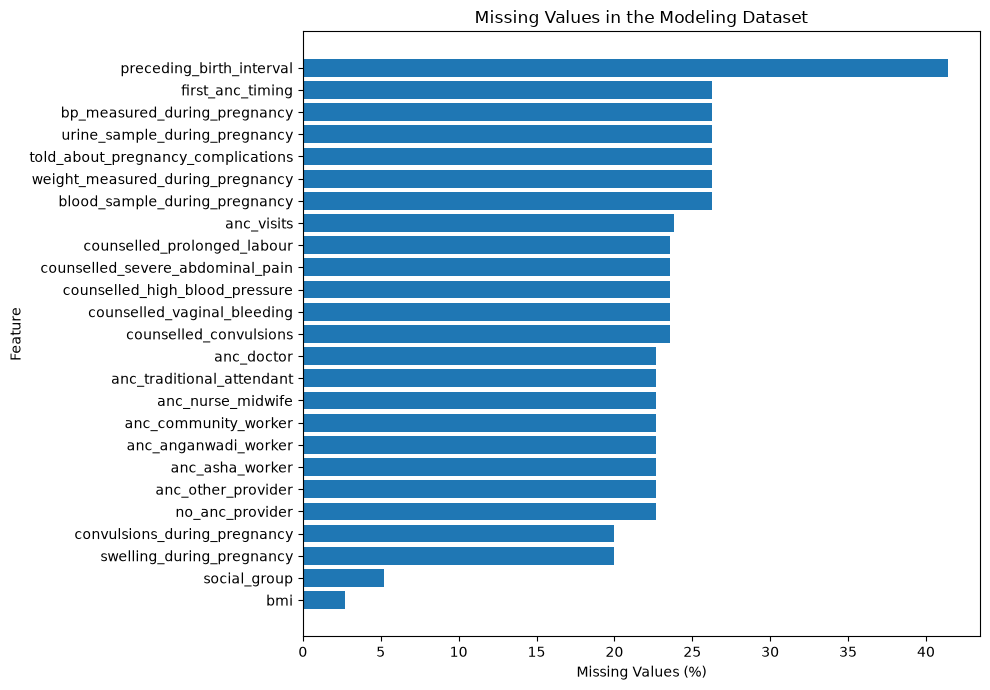

In [37]:
# Plot missing-value percentages
plt.figure(figsize=(10, 7))
plt.barh(
    missing_summary.index,
    missing_summary["missing_percent"]
)
plt.title("Missing Values in the Modeling Dataset")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation

The missing-value patterns differed across variables and therefore should not be handled using a single imputation strategy.

- BMI had relatively low missingness (2.73%) and can be imputed during the preprocessing stage.
- Social group had 5.24% missing values and can retain a separate missing category during encoding.
- The preceding birth interval had the highest proportion of missing values (41.40%), which is largely structural because the variable is not applicable to first births.
- ANC-related variables showed approximately 20–26% missingness. These missing values may indicate that ANC was not received, the information was not recorded, or the question was not applicable.

The final imputation and encoding strategy will be implemented within the machine-learning preprocessing pipeline to prevent data leakage and ensure that preprocessing is performed consistently across training and testing data.

## 15. Overall EDA Findings

The exploratory data analysis identified several variables associated with Cesarean section delivery among institutional births in the NFHS-5 dataset.

Key findings include:

- The survey-weighted Cesarean section rate was slightly higher than the unweighted rate, indicating that survey weighting modestly increased the estimated population prevalence.
- Maternal BMI, years of education, household wealth, and urban residence showed positive associations with Cesarean section delivery. Among the numeric variables, years of education demonstrated the largest effect size, although the association remained moderate.
- Women with lower birth order, fewer children, older age at first birth, longer preceding birth intervals, and multiple pregnancies had higher Cesarean section rates.
- Women who received more ANC visits and whose ANC was provided by a doctor generally had higher Cesarean section rates. These findings are likely to reflect differences in pregnancy risk and healthcare utilization rather than a direct effect of ANC itself.
- Facility type exhibited the strongest categorical association with delivery method (Cramer's V = 0.346), with substantially higher Cesarean section rates observed in private facilities than in public facilities.
- Most variables were statistically significant because of the large sample size; however, effect-size measures showed that many associations were small in magnitude, emphasizing the importance of interpreting statistical significance together with practical significance.
- Correlation analysis identified several highly correlated predictors, particularly birth order and total children ever born, as well as multiple ANC counselling variables. These relationships will be considered during feature selection and model development.
- Missing values were concentrated primarily in ANC-related variables and the preceding birth interval, indicating that different preprocessing strategies will be required for different variables.

Overall, the exploratory analysis suggests that maternal characteristics, socioeconomic factors, reproductive history, antenatal care, and healthcare facility characteristics all contribute useful information for predicting Cesarean section delivery. These findings provide a strong foundation for the subsequent preprocessing, model development, and SHAP-based explainability analyses.